In [1]:
# Install Kaggle package
!pip install kaggle

In [2]:
# Upload Kaggle API token (kaggle.json)
from google.colab import files
files.upload()  # Upload kaggle.json here

{}

In [3]:
# Move kaggle.json to proper location and set permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
# Download dataset from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:13<00:00, 188MB/s]



In [5]:
# Unzip dataset
!unzip -q chest-xray-pneumonia.zip -d /content/chest_xray

In [7]:
dataset_path = "/content/chest_xray/chest_xray"
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

Feed data in batches, normalize pixels, augment training set for better performance.

In [9]:
# Augmentation for training set to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation & Test set only rescaling
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Use DenseNet121 as feature extractor; custom head for Pneumonia detection.

In [10]:
# Load DenseNet121 with ImageNet weights, exclude top classifier
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Add custom head for binary classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers initially
for layer in base_model.layers:
    layer.trainable = False

# Model summary
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    train_gen,
    epochs=5,                  # Quick hands-on learning
    validation_data=val_gen
)

Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 151s 378ms/step - accuracy: 0.7036 - loss: 0.5682 - val_accuracy: 0.5625 - val_loss: 0.6353
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 107s 328ms/step - accuracy: 0.8177 - loss: 0.4026 - val_accuracy: 0.7500 - val_loss: 0.5309
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 108s 331ms/step - accuracy: 0.8823 - loss: 0.3182 - val_accuracy: 0.7500 - val_loss: 0.4751
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 138s 318ms/step - accuracy: 0.9053 - loss: 0.2789 - val_accuracy: 0.8125 - val_loss: 0.4475
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 107s 327ms/step - accuracy: 0.9155 - loss: 0.2492 - val_accuracy: 0.8125 - val_loss: 0.4068


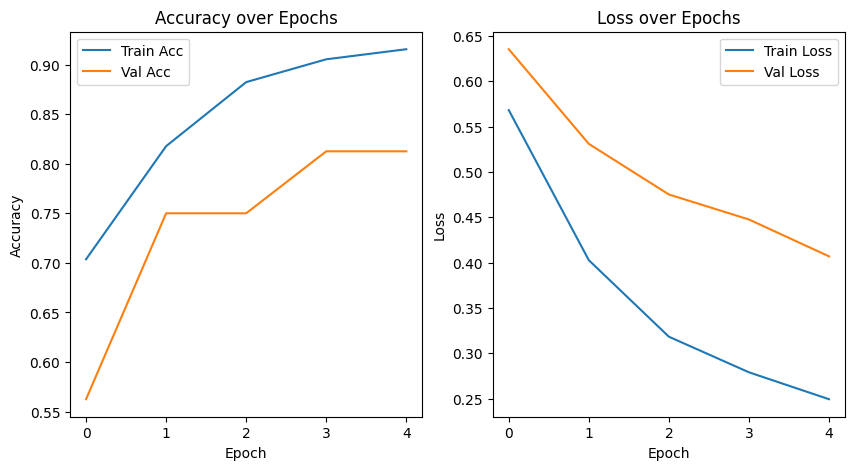

In [13]:
plt.figure(figsize=(10,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
results = model.evaluate(test_gen)
print("Test Loss, Test Accuracy:", results)

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.8141 - loss: 0.4029
Test Loss, Test Accuracy: [0.4029271900653839, 0.8141025900840759]


In [15]:
model.save("/content/pneumonia_densenet121.h5")
print("Model saved successfully!")

Model saved successfully!


In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load your trained model
model = load_model("/content/pneumonia_densenet121.h5")

In [36]:
from google.colab import files

# Get uploaded file name
img_path = "/content/chest_xray/chest_xray/chest_xray/test/NORMAL/IM-0033-0001-0002.jpeg"
print("Image uploaded:", img_path)

Image uploaded: /content/chest_xray/chest_xray/chest_xray/test/NORMAL/IM-0033-0001-0002.jpeg


In [37]:
# Load image and resize to 224x224
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale pixels
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

print("Image shape ready for model:", img_array.shape)

Image shape ready for model: (1, 224, 224, 3)


In [38]:
# Predict
pred = model.predict(img_array)

# Since it's binary classification
if pred[0][0] > 0.5:
    label = "PNEUMONIA"
else:
    label = "NORMAL"

print(f"Prediction Probability: {pred[0][0]:.4f}")
print(f"Predicted Label: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction Probability: 0.7152
Predicted Label: PNEUMONIA


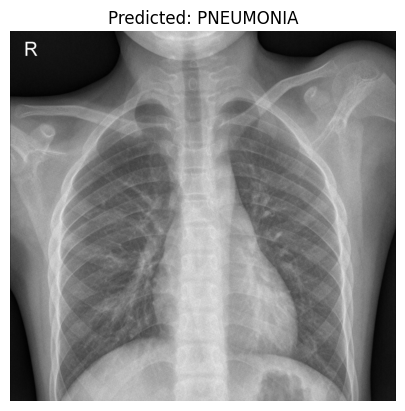

In [35]:
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {label}")
plt.axis("off")
plt.show()